In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [ ]:
# Load dataset
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']


test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
label_names=emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train=pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
    }
)
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
df_test=pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [ ]:
print(df_train.isnull().sum())
print(df_test.isnull().sum())

text     0
label    0
dtype: int64
text     0
label    0
dtype: int64


EXPLORATORY DATA ANALYSIS


<Axes: xlabel='label', ylabel='count'>

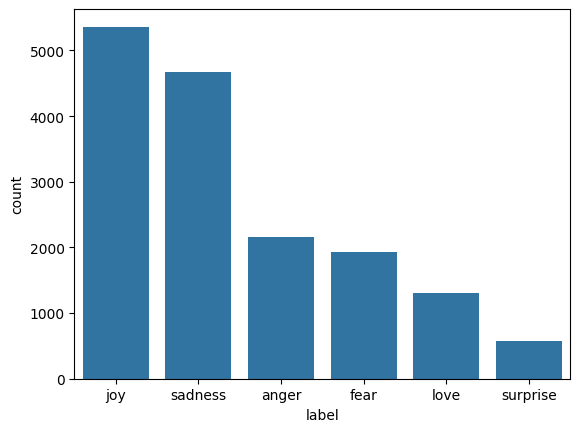

In [ ]:
sns.countplot(x='label',data=df_train, order=df_train['label'].value_counts().index)

DATA PREPROCESSING

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words=10000
tokenizer=Tokenizer(num_words=max_words, oov_token='unk')
tokenizer.fit_on_texts(df_train['text'])


train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])
test_sequence

[[17, 8, 203, 715, 15, 17, 26, 46, 5595, 114, 58],
 [17, 1, 11, 243, 37, 2, 3, 469],
 [2,
  145,
  80,
  68,
  2971,
  60,
  18,
  37,
  2,
  104,
  43,
  165,
  67,
  68,
  5,
  3,
  14,
  2,
  93,
  406,
  25,
  68],
 [2,
  172,
  25,
  11,
  1,
  10,
  873,
  4,
  5366,
  1,
  736,
  11,
  1518,
  8,
  351,
  38,
  608,
  95,
  34,
  2,
  1973],
 [2, 20, 8, 7, 56, 654, 34, 2, 127, 23, 71],
 [2, 131, 421, 106, 7, 1515, 1439, 153, 2, 39, 26, 3, 498],
 [2, 144, 974, 34, 33, 6, 228, 10, 7, 5667, 388],
 [2,
  962,
  161,
  2,
  9809,
  5,
  7,
  635,
  25,
  7,
  782,
  76,
  20,
  12,
  160,
  576,
  2771,
  4,
  1,
  865,
  6,
  1824,
  2,
  121,
  21,
  48,
  8,
  16,
  180,
  294,
  106,
  6,
  3471,
  1658,
  33,
  6,
  1858,
  10,
  3559],
 [2, 14, 5, 21, 6, 224, 1, 8, 29, 7, 1600, 723, 5, 113, 54, 59, 518, 292],
 [2,
  1,
  2,
  3,
  796,
  288,
  4,
  2369,
  1,
  108,
  2,
  338,
  24,
  19,
  125,
  129,
  79,
  118,
  48,
  7,
  202,
  4,
  17,
  27,
  29,
  1047,
  29,
  7,
 

In [ ]:
padded_train_sequence=pad_sequences(train_sequence, maxlen=50, padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence, maxlen=50, padding='post', truncating='post' )

padded_train_sequence

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]], dtype=int32)

In [ ]:
train_label=np.array(train_label)
test_label=np.array(test_label)


num_classes=len(np.unique(train_label))
print(num_classes)

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max word lenght: {padded_train_sequence.shape[1]}")

6
Vocabulary size: 15213
Max word lenght: 50


Calculating class weights for checking imbalance in classes

In [ ]:
from sklearn.utils import class_weight

classWeight=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_label),
    y=train_label
)
class_weight_dict=dict(enumerate(classWeight))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

Applying Early Stopping for models

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Embedding, Dense, Dropout

MODEL1 l: SIMPLE RNN

In [ ]:
model =  Sequential([
    Embedding(input_dim= max_words, output_dim= 128, input_length=50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy=model.evaluate(padded_test_sequence, test_label)
print(f"Rnn loss: {rnn_loss}")
print(f"Rnn_accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.1563 - loss: 2.0389 - val_accuracy: 0.0330 - val_loss: 1.8145
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - accuracy: 0.1453 - loss: 1.8776 - val_accuracy: 0.0355 - val_loss: 1.8081
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.1337 - loss: 1.8260 - val_accuracy: 0.1120 - val_loss: 1.8119
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.1241 - loss: 1.8087 - val_accuracy: 0.0795 - val_loss: 1.8007
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.1237 - loss: 1.8043 - val_accuracy: 0.1375 - val_loss: 1.7855
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.1363 - loss: 1.8008 - val_accuracy: 0.2190 - val_loss: 1.7692
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1373 - loss: 1.8001 - val_accuracy: 0.1120 - val_loss: 1.8077
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.1407 - loss: 1.8008 - 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MODEL 2: LSTM

In [ ]:
lstm_model=Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])
lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy=lstm_model.evaluate(padded_test_sequence, test_label)
print(f"LSTM loss: {lstm_loss}")
print(f"LSTM accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 125ms/step - accuracy: 0.1392 - loss: 1.7952 - val_accuracy: 0.1115 - val_loss: 1.8042
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 124ms/step - accuracy: 0.1298 - loss: 1.7939 - val_accuracy: 0.2835 - val_loss: 1.8010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 124ms/step - accuracy: 0.1416 - loss: 1.7920 - val_accuracy: 0.1270 - val_loss: 1.8236
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1115 - loss: 1.8042
LSTM loss: 1.8042300939559937
LSTM accuracy: 0.11150000244379044


MODEL 3: GRU

In [ ]:
gru_model=Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])
gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_label,
    validation_data= (padded_test_sequence,test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy=gru_model.evaluate(padded_test_sequence,test_label)
print(f"GRU loss: {gru_loss}")
print(f"GRU_accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 106ms/step - accuracy: 0.1517 - loss: 1.7961 - val_accuracy: 0.0825 - val_loss: 1.7892
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.1476 - loss: 1.7942 - val_accuracy: 0.1370 - val_loss: 1.7698
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.1660 - loss: 1.7959 - val_accuracy: 0.1395 - val_loss: 1.7886
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0825 - loss: 1.7892
GRU loss: 1.7892385721206665
GRU_accuracy: 0.08250000327825546


RANKING BEST MODEL

In [ ]:
result_df=pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Loss':[rnn_loss,lstm_loss,gru_loss],
    'Accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
}).sort_values(by='Accuracy',ascending=False)
result_df

,Model,Loss,Accuracy
0,RNN,1.745398,0.2905
1,LSTM,1.804230,0.1115
2,GRU,1.789239,0.0825


BI-DIRECTIONAL GRU

In [ ]:
from tensorflow.keras.layers import Bidirectional

biGRU=Sequential([
    Embedding(input_dim=max_words, output_dim= 300, input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

biGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

biGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
biGRU.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

bigru_loss, bigru_accuracy=biGRU.evaluate(padded_test_sequence, test_label)
print(f"BI-GRU LOSS: {bigru_loss}")
print(f"BI-GRU ACCURACY: {bigru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 155s 299ms/step - accuracy: 0.5926 - loss: 0.9846 - val_accuracy: 0.8910 - val_loss: 0.3485
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 295ms/step - accuracy: 0.9212 - loss: 0.2218 - val_accuracy: 0.9040 - val_loss: 0.2842
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 288ms/step - accuracy: 0.9453 - loss: 0.1387 - val_accuracy: 0.9220 - val_loss: 0.2418
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 285ms/step - accuracy: 0.9604 - loss: 0.1071 - val_accuracy: 0.9130 - val_loss: 0.2454
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 291ms/step - accuracy: 0.9663 - loss: 0.0922 - val_accuracy: 0.9270 - val_loss: 0.2309
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 289ms/step - accuracy: 0.9759 - loss: 0.0681 - val_accuracy: 0.9150 - val_loss: 0.2789
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 145s 290ms/step - accuracy: 0.9796 - loss: 0.0544 - val_accuracy: 0.9190 - val_loss: 0.3236
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 296ms/step - accuracy: 0.9825 -

FINAL MODEL CONFUSION MATRICES

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step


<Axes: >

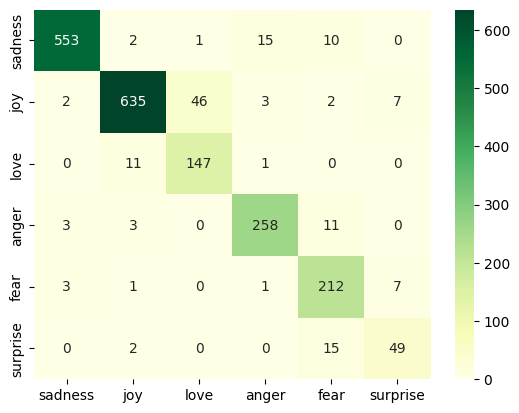

In [ ]:
from sklearn.metrics import confusion_matrix

biGRU_predictions = np.argmax(biGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, biGRU_predictions),annot=True,fmt='d',cmap='YlGn',xticklabels=label_names,yticklabels=label_names)

FINAL PREDICTIONS ON SAMPLE TEXT

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences=tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences(sample_sequences, maxlen=50, padding='post',truncating='post')


sample_predictions=np.argmax(biGRU.predict(sample_padded_sequences),axis=1)

for i in range(len(sample_texts)):
  print(f"Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


SAVING MODEL AND TOKENIZER

In [ ]:
import os
import pickle

model_dir='Artifacts'
os.makedirs(model_dir, exist_ok=True)

# Saving Bi-GRU model
biGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

# Saving the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'),'wb') as file:
  pickle.dump(tokenizer, file)